In [1]:
!pip install fredapi > /dev/null
!pip install kaggle > /dev/null
!pip install kaggle_secrets > /dev/null

ERROR: Could not find a version that satisfies the requirement kaggle_secrets (from versions: none)
ERROR: No matching distribution found for kaggle_secrets


In [6]:
import pandas as pd
import kaggle
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

plt.style.use('fivethirtyeight')
# pd.set_option('max_columns', 500)
color_pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

from fredapi import Fred

fred_key = "e17718e9e426e93a1f93fd838e84fb61"

## Create the FRED Object

In [8]:
fred = Fred(api_key = fred_key)

## Search for Economic Data

In [9]:
sp_search = fred.search('S&P', order_by='popularity')

In [10]:
sp_search.head()

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
BAMLH0A0HYM2,BAMLH0A0HYM2,2023-11-29,2023-11-29,ICE BofA US High Yield Index Option-Adjusted S...,1996-12-31,2023-11-28,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2023-11-29 08:20:02-06:00,94,The ICE BofA Option-Adjusted Spreads (OASs) ar...
CSUSHPINSA,CSUSHPINSA,2023-11-29,2023-11-29,S&P/Case-Shiller U.S. National Home Price Index,1987-01-01,2023-09-01,Monthly,M,Index Jan 2000=100,Index Jan 2000=100,Not Seasonally Adjusted,NSA,2023-11-28 08:12:02-06:00,90,"For more information regarding the index, plea..."
SP500,SP500,2023-11-29,2023-11-29,S&P 500,2013-11-29,2023-11-28,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2023-11-28 19:11:02-06:00,84,The observations for the S&P 500 represent the...
BAMLH0A0HYM2EY,BAMLH0A0HYM2EY,2023-11-29,2023-11-29,ICE BofA US High Yield Index Effective Yield,1996-12-31,2023-11-28,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2023-11-29 08:20:08-06:00,83,This data represents the effective yield of th...
MEHOINUSA672N,MEHOINUSA672N,2023-11-29,2023-11-29,Real Median Household Income in the United States,1984-01-01,2022-01-01,Annual,A,2022 CPI-U-RS Adjusted Dollars,2022 CPI-U-RS Adjusted $,Not Seasonally Adjusted,NSA,2023-09-12 13:48:02-05:00,82,Household data are collected as of March. As ...


## Pull Raw Data & Plot

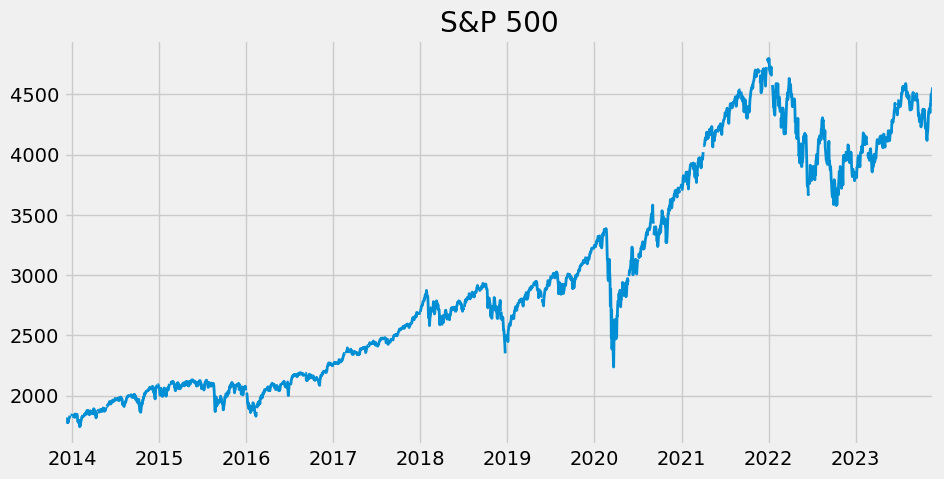

In [14]:
sp500 = fred.get_series(series_id = 'SP500')
sp500.plot(figsize=(10,5), title = 'S&P 500', lw=2)
plt.show()

## Pull and Join Multiple Data Series

In [16]:
unemp_df = fred.search('unemployment rate state', filter=('frequency','Monthly'))
unemp_df = unemp_df.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')
unemp_df = unemp_df.loc[unemp_df['title'].str.contains('Unemployment Rate')]

In [ ]:
all_results -